# Demo 1: Visualizing Model Bias with Fairness & Explainability

**Time:** ~30–45 minutes

Train a Random Forest on `adult.csv`, audit fairness with **Fairlearn**, and explain predictions with **SHAP**.


# Teaching Guide

## Learning Objectives
- Train and evaluate a Random Forest classifier.
- Audit selection rates and demographic parity with Fairlearn.
- Use SHAP for global and local explanations.
- Discuss fairness limitations and mitigation options.

## Core Ideas
- **Fairness:** Compare outcomes across sensitive groups.
- **Global explainability:** Which features matter overall?
- **Local explainability:** What drove one prediction?
- **Caution:** SHAP explains model behavior, not causality.

## Key Metrics
- **Precision:** How many predicted positives were correct?
- **Recall:** How many actual positives were found?
- **F1:** Balance of precision and recall.
- **Selection rate:** Fraction receiving a positive prediction.
- **Demographic parity difference:** Gap in selection rates across groups.

**Reflect:** Can a model be accurate but unfair? Which fairness metric fits the use case?


## Global SHAP

Use the SHAP bar chart to see which features influence predictions most **overall**.

**Look for:** larger bars = greater average impact. Global importance shows model reliance, not causality.


## Local SHAP

Use the waterfall plot to explain **one prediction**.

**Look for:** features pushing the prediction up or down from the base value. Local explanations apply only to the selected row.


## Environment Setup

Install packages if needed.


In [ ]:

# Install dependencies if needed:
!pip -q install pandas scikit-learn matplotlib seaborn shap fairlearn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.8 MB/s eta 0:00:00


## 1) Imports and Global Config


In [ ]:

import warnings, os, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

# Fairlearn metrics
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference

# SHAP
import shap

# Progress
from tqdm.auto import tqdm

# Plot defaults
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True


## 2) Load the Adult Census Income Dataset


In [ ]:
CSV_PATHS = ["adult.csv", "/adult.csv"]  # local or Colab
csv_path = next((p for p in CSV_PATHS if os.path.exists(p)), None)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'adult.csv'. Place it in the session root (e.g., /content/adult.csv) and rerun."
    )

# CSV has no header
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

data = pd.read_csv(csv_path, header=None, names=column_names)
print("Loaded:", csv_path)
display(data.head())

Loaded: /adult.csv


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


> **Optional:** Uncomment the next cell to upload `adult.csv` manually in Colab.


In [ ]:

# from google.colab import files
# uploaded = files.upload()  # choose adult.csv
# import pandas as pd
# data = pd.read_csv('adult.csv')
# data.head()


> **Concept:** Fairness asks whether outcomes differ across groups; explainability asks why the model made its predictions. SHAP describes model associations, not causality.


## 3) Quick Data Check

Inspect shape, missing values, and the target distribution.


In [ ]:
print("Rows, Columns:", data.shape)
print("\nMissing values per column (top 10):\n", data.isna().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution (income):")
print(data['income'].value_counts(dropna=False))

Rows, Columns: (32561, 15)

Missing values per column (top 10):
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
dtype: int64

Target distribution (income):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


## 4) Minimal Preprocessing

Use a compact feature set and one-hot encode `sex` and `race`.


In [ ]:

# Handle common column-name variants
candidate_cols = {
    "education_num": ["education-num", "education.num", "education_num"],
    "hours_per_week": ["hours-per-week", "hours.per.week", "hours_per_week"],
}

def pick_col(d, options, fallback=None):
    for c in options:
        if c in d.columns:
            return c
    if fallback is not None and fallback in d.columns:
        return fallback
    raise KeyError(f"Could not find any of columns: {options + ([fallback] if fallback else [])}")

edu_col = pick_col(data, candidate_cols["education_num"])
hrs_col = pick_col(data, candidate_cols["hours_per_week"])

selected_cols = ["age", edu_col, "sex", "race", hrs_col, "income"]
df = data[selected_cols].copy()

# Normalize names
df = df.rename(columns={edu_col: "education_num", hrs_col: "hours_per_week"})

# Binary label
df['income'] = df['income'].apply(lambda x: 1 if str(x).strip() == '>50K' else 0)

# Encode categorical features
df = pd.get_dummies(df, columns=['sex','race'], drop_first=True)

# Split data
X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((26048, 8), (6513, 8))

## 5) Train and Evaluate the Random Forest

Tree-based models do not require feature scaling.


Accuracy: 0.7844311377245509

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      4945
           1       0.57      0.44      0.49      1568

    accuracy                           0.78      6513
   macro avg       0.70      0.67      0.68      6513
weighted avg       0.77      0.78      0.77      6513



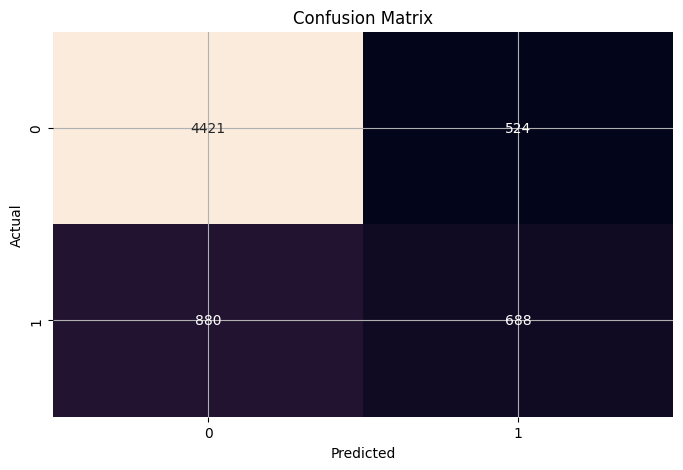

In [ ]:

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 6) Audit Fairness with Fairlearn

Compare **selection rates** across groups and compute **demographic parity difference**. A smaller gap indicates greater parity.


In [ ]:

# Sensitive features
sensitive_cols = [c for c in X_test.columns if c.startswith("sex_") or c.startswith("race_")]
print("Sensitive columns used for auditing:", sensitive_cols)

sens_df = pd.DataFrame(index=X_test.index)
sens_df['sex_Male'] = X_test['sex_Male'] if 'sex_Male' in X_test.columns else 0
sens_df['race_White'] = X_test['race_White'] if 'race_White' in X_test.columns else 0

mf = MetricFrame(
    metrics=selection_rate,
    y_true=y_test,
    y_pred=pred,
    sensitive_features=sens_df
)

print("Selection rate by group (sex_Male x race_White):")
display(mf.by_group)

if 'sex_Male' in X_test.columns:
    dp_sex = demographic_parity_difference(
        y_true=y_test, y_pred=pred, sensitive_features=X_test['sex_Male']
    )
    print(f"Demographic Parity Difference (sex): {dp_sex:.3f}")
else:
    print("Demographic Parity Difference (sex): N/A (no sex_Male column)")


Sensitive columns used for auditing: ['sex_ Male', 'race_ Asian-Pac-Islander', 'race_ Black', 'race_ Other', 'race_ White']
Selection rate by group (sex_Male x race_White):


,,selection_rate
sex_Male,race_White,
0,0,0.186089


Demographic Parity Difference (sex): N/A (no sex_Male column)


## 7) Global Explainability with SHAP

Compute SHAP values and visualize overall feature importance and distribution.


In [ ]:

# 7.1 Impute
imputer = SimpleImputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# 7.2 TreeExplainer
explainer = shap.TreeExplainer(clf)

# 7.3 Compute SHAP in chunks
def compute_shap_in_chunks(explainer, X, chunk_size=512):
    """Compute SHAP values in chunks so we can show a tqdm progress bar.
    Handles both legacy (list-of-arrays) and new Explanation API outputs.
    Returns (sv, class_idx): sv is a 2D array [n_samples, n_features] for the positive class if binary.
    """
    n = X.shape[0]
    sv_list = []
    class_idx = 0

    for start in tqdm(range(0, n, chunk_size), desc="Computing SHAP", unit="rows"):
        end = min(start + chunk_size, n)
        X_chunk = X[start:end]

        try:
            vals = explainer.shap_values(X_chunk)
            if isinstance(vals, list):        # legacy API
                class_idx = 1 if len(vals) > 1 else 0
                sv_chunk = vals[class_idx]
            else:
                sv_chunk = vals
        except Exception:
            # newer API
            exp = explainer(X_chunk)
            sv_chunk = exp.values

        sv_list.append(sv_chunk)

    sv = np.vstack(sv_list)
    return sv, class_idx

sv, class_idx = compute_shap_in_chunks(explainer, X_test_imp, chunk_size=1024)

# 7.4 Global importance
shap.summary_plot(sv, X_test, plot_type="bar", show=True)


Computing SHAP:   0%|          | 0/7 [00:00<?, ?rows/s]

KeyboardInterrupt: 

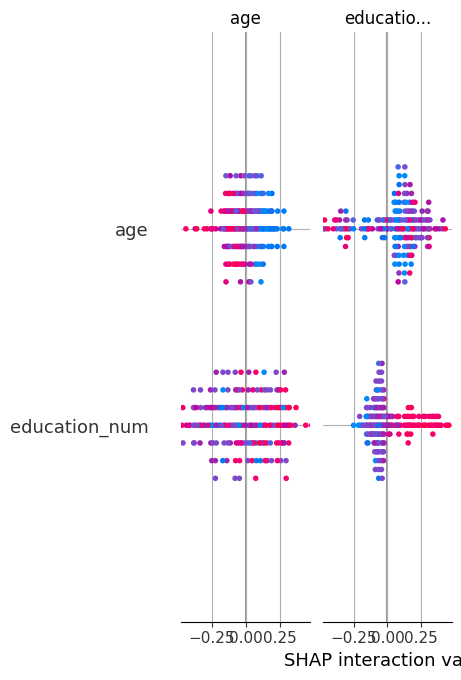

In [ ]:

# 7.5 Global distribution
shap.summary_plot(sv, X_test, show=True)


## 8) Local Explainability

Use a waterfall plot to show how features contribute to one prediction.


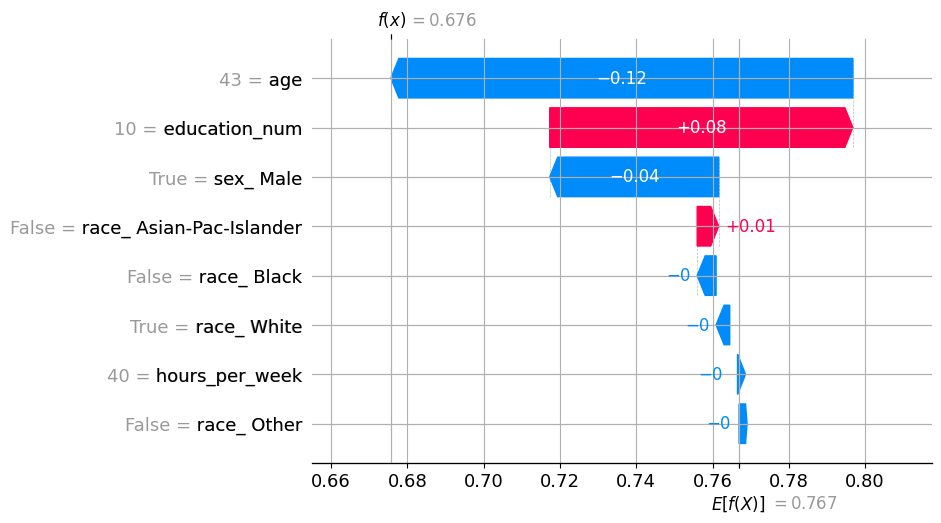

In [ ]:
# Row to inspect
i = 0

# Handle scalar or per-class base value
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    base_val = expected_value[class_idx]
else:
    base_val = expected_value

# Positive-class SHAP values
shap_values_positive_class = sv[i, :, class_idx] if sv.ndim == 3 else sv[i]

ex = shap.Explanation(
    values=shap_values_positive_class,
    base_values=base_val,
    data=X_test.iloc[i, :].values,
    feature_names=X_test.columns.tolist()
)
shap.plots.waterfall(ex)

## 9) Reflection

- How do accuracy and fairness compare?
- Which features matter most?
- What could cause group disparities?
- Which mitigation approach would you test?


## 10) Optional Extensions

1. Compute Equalized Odds.
2. Try Logistic Regression.
3. Add features and compare SHAP importance.
4. Tune the decision threshold.
5. Try Fairlearn mitigation.


## 11) Key Takeaways

- Accuracy does not guarantee fairness.
- Fairlearn measures outcomes by group.
- SHAP supports global and local explanations.
- Responsible ML requires ongoing evaluation.


## Appendix: Reproducibility & Versions


In [ ]:

import sys, sklearn, fairlearn, shap as _shap, tqdm as _tqdm
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("fairlearn:", fairlearn.__version__)
print("shap:", _shap.__version__)
print("tqdm:", _tqdm.__version__)


Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1
fairlearn: 0.14.0
shap: 0.52.0
tqdm: 4.67.3
